In [106]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
import numpy as np
import seisbench.data as sbd
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import time

from models import ResidualBlock, CausalConv1d  

In [107]:
import seisbench.data as sbd
import pandas as pd

dataset = sbd.STEAD()
metadata = dataset.metadata

# ---- FILTER ----
eq_mask = (
    (metadata["trace_category"] == "earthquake_local") &
    (metadata["trace_p_arrival_sample"].notna()) &
    (metadata["trace_s_arrival_sample"].notna()) &
    (metadata["trace_p_arrival_sample"] < 3000) &
    (metadata["trace_s_arrival_sample"] < 3000)
)

noise_mask = metadata["trace_category"] == "noise"

filtered_metadata = metadata[eq_mask | noise_mask].reset_index(drop=True)

print("Filtered:", len(filtered_metadata))

2026-04-22 12:31:45,568 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.


Filtered: 1239998


In [108]:
eq_data = filtered_metadata[filtered_metadata["trace_category"]=="earthquake_local"]
noise_data = filtered_metadata[filtered_metadata["trace_category"]=="noise"]

eq_subset = eq_data.sample(n=40000, random_state=42)
noise_subset = noise_data.sample(n=10000, random_state=42)

subset_metadata = pd.concat([eq_subset, noise_subset]).reset_index(drop=True)

In [109]:
import numpy as np

def compute_sta_lta(waveform, sta=50, lta=500, eps=1e-8):

    energy = np.sum(waveform**2, axis=0)

    sta_vals = np.convolve(energy, np.ones(sta)/sta, mode="same")
    lta_vals = np.convolve(energy, np.ones(lta)/lta, mode="same")

    ratio = sta_vals / (lta_vals + eps)
    ratio = ratio / (np.max(ratio) + eps)

    return ratio.astype(np.float32)

In [110]:
# def gaussian_pick(arrival, length=3000, sigma=15):

#     t = np.arange(length)

#     return np.exp(-(t-arrival)**2/(2*sigma**2)).astype(np.float32)

def gaussian_pick_p(arrival, length=3000, sigma=8):
    t = np.arange(length)
    return np.exp(-(t-arrival)**2/(2*sigma**2)).astype(np.float32)

def gaussian_pick_s(arrival, length=3000, sigma=20):
    t = np.arange(length)
    return np.exp(-(t-arrival)**2/(2*sigma**2)).astype(np.float32)

In [111]:
import torch
from torch.utils.data import Dataset

class Phase2Dataset(Dataset):

    def __init__(self, dataset, metadata):
        self.dataset = dataset
        self.metadata = metadata

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):

        meta = self.metadata.iloc[idx]

        # Load waveform (only needed part)
        wf = self.dataset.get_waveforms([idx])[0][:,:3000].astype(np.float32)

        # Detection label
        y_det = 1.0 if meta["trace_category"]=="earthquake_local" else 0.0

        # STA/LTA
        sta_lta = compute_sta_lta(wf)

        x = np.vstack([wf, sta_lta])

        # Phase targets
        if y_det == 1.0:
            p_arr = int(meta["trace_p_arrival_sample"])
            s_arr = int(meta["trace_s_arrival_sample"])

            y_p = gaussian_pick_p(p_arr)
            y_s = gaussian_pick_s(s_arr)
        else:
            y_p = np.zeros(3000, dtype=np.float32)
            y_s = np.zeros(3000, dtype=np.float32)

        return (
            torch.from_numpy(x),
            torch.tensor([y_det], dtype=torch.float32),
            torch.from_numpy(y_p),
            torch.from_numpy(y_s)
        )

In [112]:
from torch.utils.data import DataLoader

train_dataset = Phase2Dataset(dataset, subset_metadata)

loader = DataLoader(
    train_dataset,
    batch_size=4,     # IMPORTANT (GPU limit)
    shuffle=True,
    num_workers=0     # STABLE for notebook
)

In [113]:
class Phase2MultiTaskTCN(nn.Module):

    def __init__(self):
        super().__init__()

        # Input projection (4 channels now: Z, N, E, STA/LTA)
        self.input_conv = nn.Conv1d(4, 32, kernel_size=1)

        dilations = [1,2,4,8,16,32,64,128]

        self.blocks = nn.Sequential(
            *[ResidualBlock(32,5,d) for d in dilations]
        )

        # Detection head (same idea as Phase-1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32,1)

        # Phase heads
# Phase heads (FIXED)
        self.p_head = nn.Sequential(
            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 1, kernel_size=1)
        )

        self.s_head = nn.Sequential(
            nn.Conv1d(32, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 1, kernel_size=1)
        )

    def forward(self,x):

        x = self.input_conv(x)
        features = self.blocks(x)          # (B,32,3000)

        # Detection branch
        det = self.pool(features).squeeze(-1)
        det = self.fc(det)

        # Phase picking branches
        p_map = self.p_head(features).squeeze(1)
        s_map = self.s_head(features).squeeze(1)

        return det, p_map, s_map

In [114]:
model = Phase2MultiTaskTCN()

checkpoint = torch.load("../res_models/backbone_models/checkpoint_epoch9.pth", map_location="cpu")
state_dict = checkpoint["model_state_dict"]

# load weights
model.input_conv.weight.data[:, :3] = state_dict["input_conv.weight"]
model.input_conv.bias.data = state_dict["input_conv.bias"]

blocks_state = {
    k.replace("blocks.", ""): v
    for k,v in state_dict.items() if k.startswith("blocks.")
}
model.blocks.load_state_dict(blocks_state)

model.fc.weight.data = state_dict["fc.weight"]
model.fc.bias.data = state_dict["fc.bias"]

In [115]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [116]:
for p in model.blocks.parameters():
    p.requires_grad = False

for p in model.input_conv.parameters():
    p.requires_grad = False

In [117]:
det_loss_fn = torch.nn.BCEWithLogitsLoss()
phase_loss_fn = torch.nn.BCELoss(reduction='none')

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

In [118]:
# # ===== UNFREEZE BACKBONE =====

# for p in model.parameters():
#     p.requires_grad = True

In [119]:
for epoch in range(5):

    model.train()
    total_loss = 0

    for x, y_det, y_p, y_s in loader:

        x = x.to(device)
        y_det = y_det.to(device)
        y_p = y_p.to(device)
        y_s = y_s.to(device)

        optimizer.zero_grad()

        det_out, p_out, s_out = model(x)

        # clamp for stability
        # p_out = torch.clamp(p_out, 1e-4, 1-1e-4)
        # s_out = torch.clamp(s_out, 1e-4, 1-1e-4)

        p_out = torch.clamp(p_out, 0, 1)
        s_out = torch.clamp(s_out, 0, 1)       
        L_det = det_loss_fn(det_out, y_det)
        L_p = phase_loss_fn(p_out, y_p)
        L_s = phase_loss_fn(s_out, y_s)

        p_idx = torch.argmax(p_out, dim=1)
        s_idx = torch.argmax(s_out, dim=1)

# penalty if P >= S
        phase_loss_fn = torch.nn.MSELoss(reduction='none')


        p_weight = 1 + 20*y_p
        s_weight = 1 + 20*y_s

        # L_p = (L_p * p_weight).mean()
        # L_s = (L_s * s_weight).mean()

        L_p = (L_p * p_weight).sum() / (p_weight.sum() + 1e-6)
        L_s = (L_s * s_weight).sum() / (s_weight.sum() + 1e-6)
# ---- Peak Localization Loss ----
        # p_pred_idx = torch.argmax(p_out, dim=1)
        # s_pred_idx = torch.argmax(s_out, dim=1)

        # p_true_idx = torch.argmax(y_p, dim=1)
        # s_true_idx = torch.argmax(y_s, dim=1)

        # L_peak = F.l1_loss(p_pred_idx.float(), p_true_idx.float()) + \
        #         F.l1_loss(s_pred_idx.float(), s_true_idx.float())
        


# Only apply peak loss for earthquake samples
        eq_mask = y_det.squeeze(1) > 0.5   # (B,)

        if eq_mask.sum() > 0:
                p_pred_idx = torch.argmax(p_out[eq_mask], dim=1)
                s_pred_idx = torch.argmax(s_out[eq_mask], dim=1)

                p_true_idx = torch.argmax(y_p[eq_mask], dim=1)
                s_true_idx = torch.argmax(y_s[eq_mask], dim=1)

                L_peak = F.l1_loss(p_pred_idx.float(), p_true_idx.float()) + \
                F.l1_loss(s_pred_idx.float(), s_true_idx.float())
        else:
                L_peak = torch.tensor(0.0, device=device)
        loss = L_det + 3*L_p + 3*L_s + 2.0 * L_peak
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        # print(y_p.max(), y_s.max())
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.4f}")
    if epoch == 0 and total_loss == 0:
        print("det_out mean:", det_out.mean().item())
        print("p_out mean:", p_out.mean().item())
        print("s_out mean:", s_out.mean().item())

Epoch 1 | Loss: 4163.5071
Epoch 2 | Loss: 3912.2903
Epoch 3 | Loss: 3881.7702


KeyboardInterrupt: 

In [ ]:
print("True P:", torch.argmax(y_p[0]).item())
print("Pred P:", torch.argmax(p_out[0]).item())

print("True S:", torch.argmax(y_s[0]).item())
print("Pred S:", torch.argmax(s_out[0]).item())

True P: 400
Pred P: 528
True S: 1223
Pred S: 1929


In [ ]:
batch = next(iter(loader))
x, y_det, y_p, y_s = batch

print(x.shape)
print(torch.isnan(x).sum())

torch.Size([4, 4, 3000])
tensor(0)


In [ ]:
model.eval()

x, y_det, y_p, y_s = next(iter(loader))
x = x.to(device)

with torch.no_grad():
    det_out, p_out, s_out = model(x)
    

print("Detection:", torch.sigmoid(det_out[0]))
print("P peak:", torch.argmax(p_out[0]).item())
print("S peak:", torch.argmax(s_out[0]).item())

print("True P:", torch.argmax(y_p[0]).item())
print("True S:", torch.argmax(y_s[0]).item())

Detection: tensor([0.9957], device='cuda:0')
P peak: 829
S peak: 1653
True P: 502
True S: 571


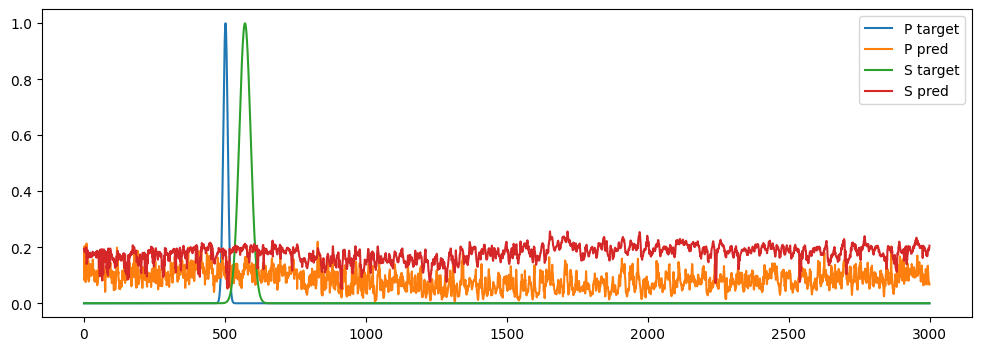

In [ ]:
import matplotlib.pyplot as plt

idx = 0

plt.figure(figsize=(12,4))

plt.plot(y_p[idx].cpu(), label="P target")
plt.plot(p_out[idx].cpu(), label="P pred")

plt.plot(y_s[idx].cpu(), label="S target")
plt.plot(s_out[idx].cpu(), label="S pred")

plt.legend()
plt.show()